# jjh

---

**Project**
- CCRM

**Module**
- notebooks

**Author**
- Hyeok

**Created**
- 2026-03-07

**Purpose**
- TODO: Clustering, PCA

---


In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
# 1. 인코딩된 데이터 불러오기
# 원핫 인코딩 등 전처리가 완료된 분석용 최종 데이터셋 로드
# 경로 수정 시 이 부분만 변경하면 되도록 상대 경로 유지
df_ready = pd.read_csv('./data/df_encoded_final.csv')

In [3]:
# 2. 전처리: 숫자형 데이터만 스케일링 (StandardScaler)
# K-Means/PCA는 거리 기반 알고리즘이므로 특성 간 단위(Scale)를 맞추는 과정 필수
# bool 타입 등 숫자로 변환 가능한 모든 컬럼을 추출하여 연산 오류 방지
X = df_ready.select_dtypes(include=[np.number])

In [4]:
# 스케일링 전 데이터 유효성 검사 (결측치 존재 시 StandardScaler에서 에러 발생)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# 3. PCA 차원 축소 (2차원으로 압축하여 시각화 대비)
# 고차원 데이터를 2개의 주성분(PC)으로 축합하여 클러스터 간 분리 정도를 2D 평면에 투영
# n_components=2: 시각적 직관성을 위해 설정
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [6]:
# 4. K-Means 클러스터링 (Elbow Method 기반 최적 k=4 가정)
# 분석을 통해 도출된 최적의 K(4) 적용 및 결과 재현성(Reproducibility)을 위해 random_state 고정
# n_init=10: 초기 중심점 위치에 따른 국소 최적해(Local Minima) 문제를 방지하기 위해 10번 반복 수행
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

In [7]:
# 원본 데이터프레임에 할당된 군집 번호를 결합하여 최종 분석(Profiling) 준비
df_ready['Cluster'] = kmeans.fit_predict(X_pca)

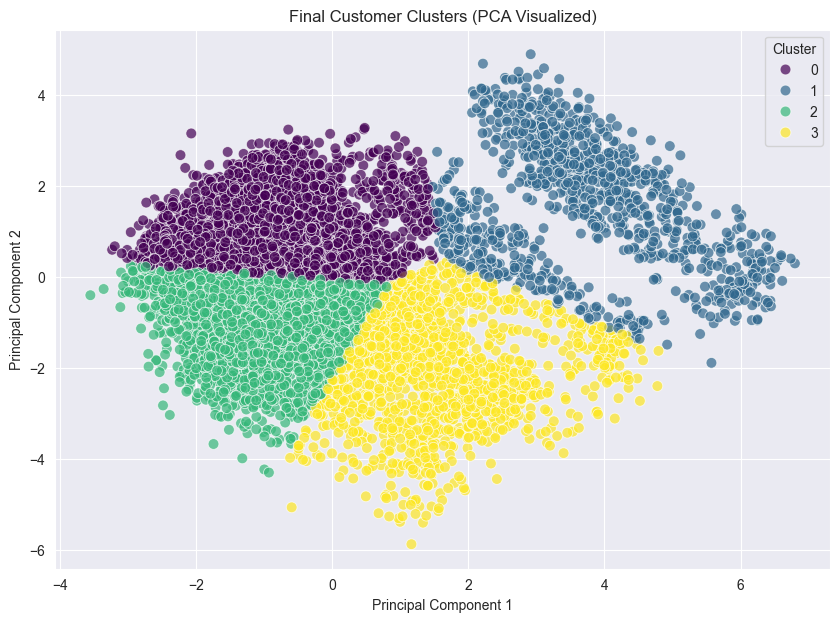

In [12]:
# 5. [시각화] PCA 군집 결과 확인
# 축소된 주성분 1, 2를 축으로 삼아 군집이 실제 공간에서 잘 나뉘었는지 시각적으로 검토
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df_ready['Cluster'],
    palette='viridis', s=60, alpha=0.7
)
plt.title('Final Customer Clusters (PCA Visualized)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [10]:
# 6. 최종 결과 저장 (군집 ID가 포함된 데이터)
# 데이터셋에 'Cluster' 라벨이 포함된 최종 CSV를 생성하여 이후 마케팅 전략 수립 등에 활용
df_ready.to_csv('./data/df_with_clusters.csv', index=False)
print(f"✅ 클러스터링 완료 (행 개수: {len(df_ready)}) 및 최종 파일 저장 완료")

✅ 클러스터링 완료 (행 개수: 10127) 및 최종 파일 저장 완료
